# CPD profiles at 4h- and 8h-specific differential regions

Comparison of CPD RPKM around noUV-specific and UV-timepoint-specific differential peak centers. The profiles cover ±50 kb in 100 windows of 1 kb.

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROFILE_DIR = Path(
    '/cta/users/guneyn23/diffbind/no_summits/'
    'differential_peak_center_100kb_100windows/plots'
)
SUMMARY_FILE = PROFILE_DIR / 'mean_rpkm_profiles_100kb.tsv'

profiles = pd.read_csv(SUMMARY_FILE, sep='\t')

COLORS = {
    'noUV': '#0072B2',
    'time': '#D55E00',
}

comparisons = {
    '4h': ('4h_noUV_specific', '4h_specific'),
    '8h': ('8h_noUV_specific', '8h_specific'),
}

def plot_comparison(time_point, value_column, profile_label, y_label, output_label, y_lim=None):
    no_uv_group, time_group = comparisons[time_point]
    data = profiles[(profiles['damage_type'] == 'CPD') & (profiles['time_point'] == time_point)]
    no_uv = data[data['peak_group'] == no_uv_group]
    time_specific = data[data['peak_group'] == time_group]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(no_uv['distance_kb'], no_uv[value_column], color=COLORS['noUV'], linewidth=2.5, label=f'{time_point} noUV-specific regions')
    ax.plot(time_specific['distance_kb'], time_specific[value_column], color=COLORS['time'], linewidth=2.5, label=f'{time_point}-specific regions')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    if value_column == 'real_sim_ratio':
        ax.axhline(1, color='black', linestyle='--', linewidth=1)
    ax.set(xlim=(-50, 50), xlabel='Distance from differential peak center (kb)', ylabel=y_label)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_xticks([-50, -25, 0, 25, 50])
    ax.set_title(f'{time_point} {profile_label} CPD around differential-accessibility regions')
    ax.legend(frameon=False)
    ax.grid(True, linestyle='--', alpha=0.35)
    fig.tight_layout()
    fig.savefig(PROFILE_DIR / f'CPD_{time_point}_noUV_vs_time_specific_100kb_{output_label}.png', dpi=300, bbox_inches='tight')
    plt.show()

profiles.head()

,peak_group,damage_type,time_point,window,distance_kb,mean_real_rpkm_raw,mean_simulated_rpkm_raw,mean_real_rpkm,mean_simulated_rpkm,real_sim_ratio
0,4h_noUV_specific,CPD,1m,1,-49.5,0.324830,0.303097,0.312150,0.306563,1.018225
1,4h_noUV_specific,CPD,1m,2,-48.5,0.312841,0.305937,0.310490,0.304979,1.018071
2,4h_noUV_specific,CPD,1m,3,-47.5,0.298778,0.310653,0.312023,0.305034,1.022911
3,4h_noUV_specific,CPD,1m,4,-46.5,0.305511,0.300227,0.307074,0.305091,1.006500
4,4h_noUV_specific,CPD,1m,5,-45.5,0.318153,0.305256,0.304557,0.303739,1.002694


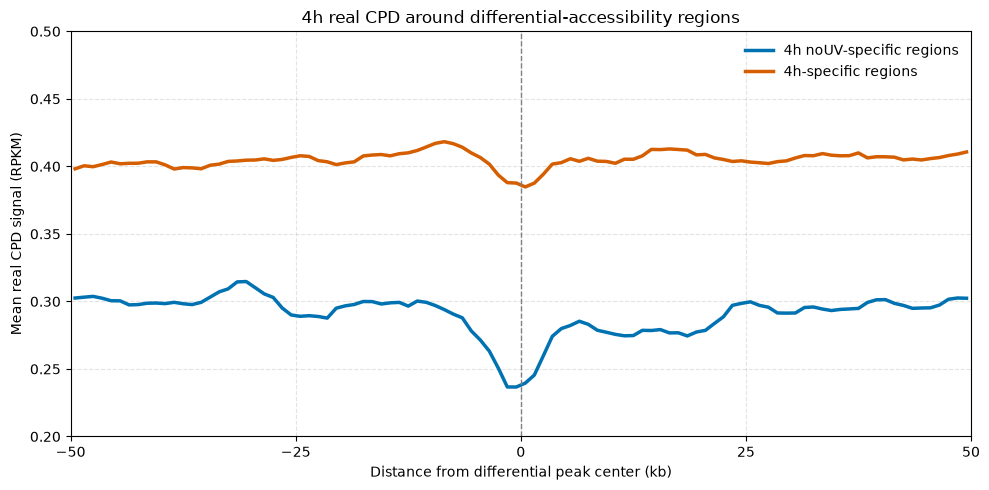

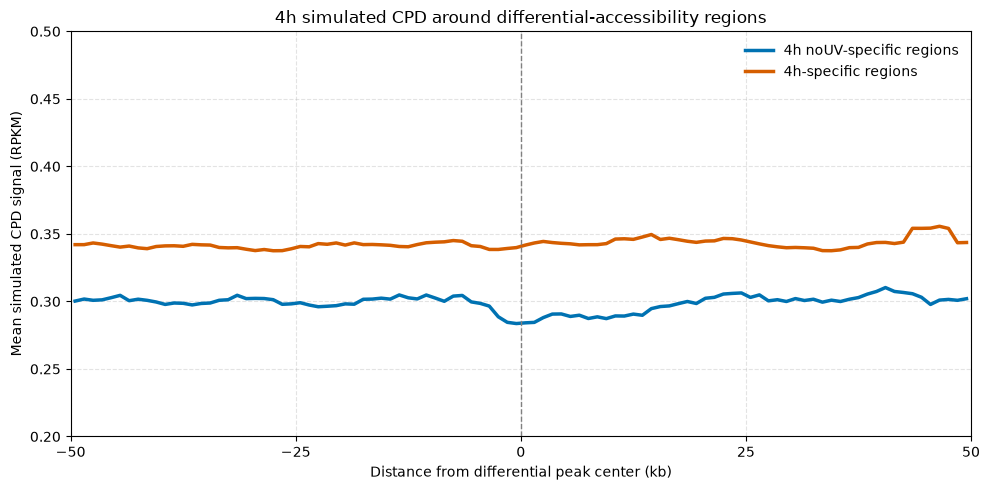

In [ ]:
# 4h real and simulated CPD as two separate figures
YLIM = (0.2, 0.5)

plot_comparison('4h', 'mean_real_rpkm', 'real', 'Mean real CPD signal (RPKM)', 'real', YLIM)
plot_comparison('4h', 'mean_simulated_rpkm', 'simulated', 'Mean simulated CPD signal (RPKM)', 'simulated', YLIM)

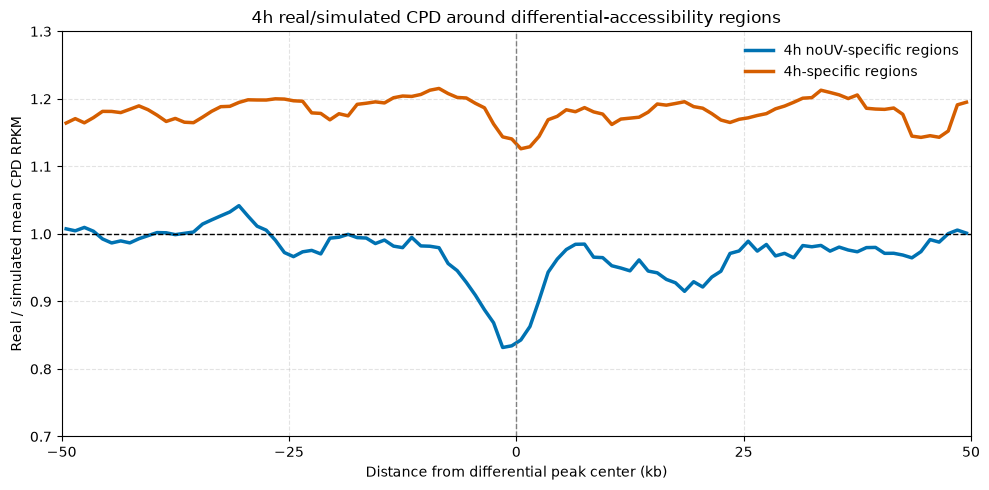

In [21]:
# 4h real/simulated CPD
YLIM = (0.7, 1.3)
plot_comparison('4h', 'real_sim_ratio', 'real/simulated', 'Real / simulated mean CPD RPKM', 'real_sim_ratio', YLIM)

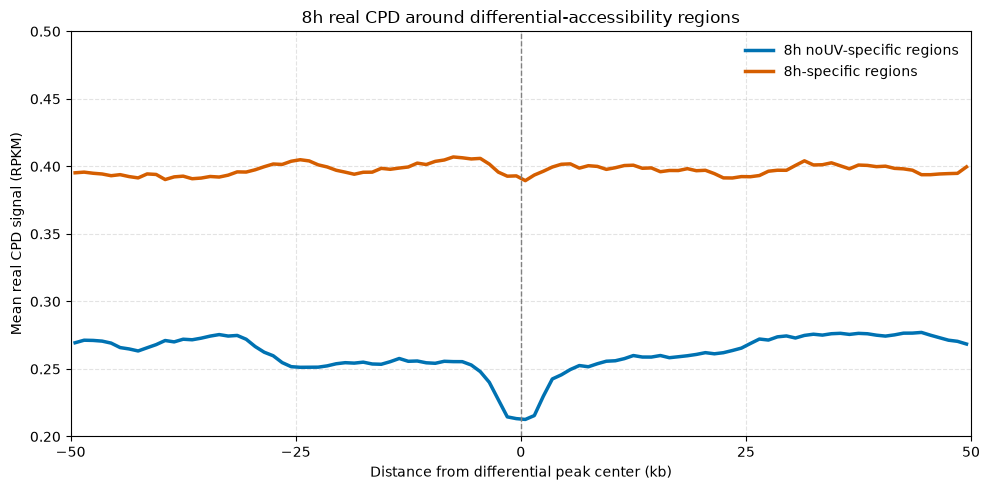

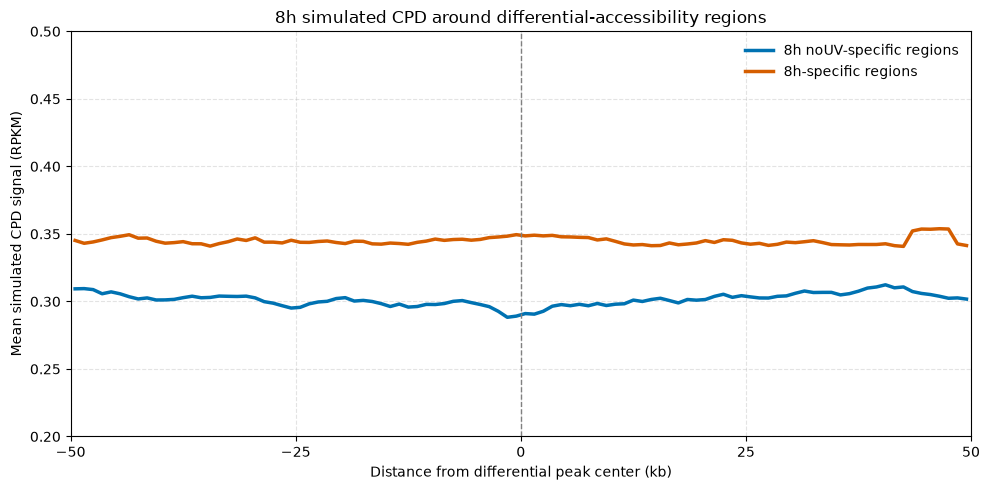

In [19]:
# 8h real and simulated CPD as two separate figures
YLIM = (0.2, 0.5)

plot_comparison('8h', 'mean_real_rpkm', 'real', 'Mean real CPD signal (RPKM)', 'real', YLIM)
plot_comparison('8h', 'mean_simulated_rpkm', 'simulated', 'Mean simulated CPD signal (RPKM)', 'simulated', YLIM)

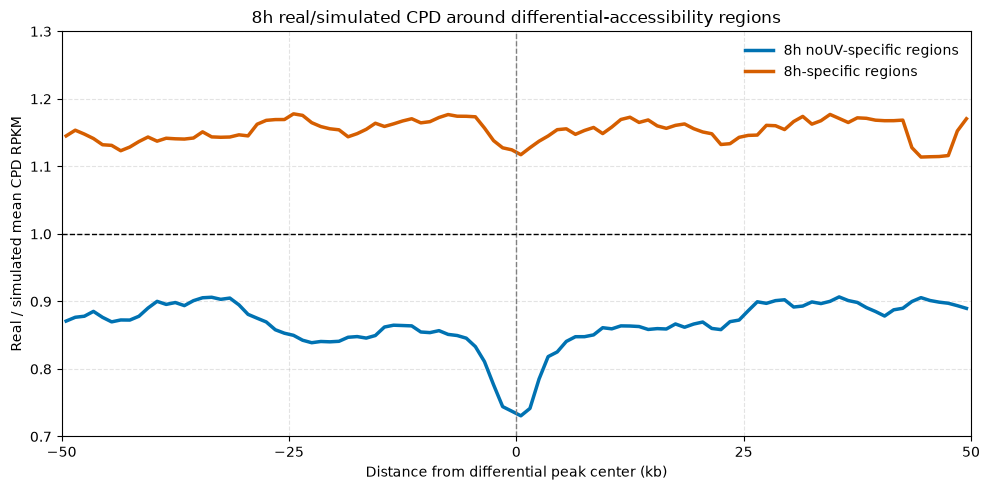

In [22]:
# 8h real/simulated CPD
YLIM = (0.7, 1.3)
plot_comparison('8h', 'real_sim_ratio', 'real/simulated', 'Real / simulated mean CPD RPKM', 'real_sim_ratio', YLIM)